<a href="https://colab.research.google.com/github/schoewu/DSF-DCBP/blob/main/04_Dataframes_Stats_Plotting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4.1 Plotting and Descriptive Statistics on Dataframes

# Minimal plotting

First we give a very minimalistic introduction to plotting which allows you to create line or scatter plots as well as histograms. For this we introduce here the Matplotlib library, which is the oldest and still one of the most widely used plotting library.

We start by importing it. Almost all the most important functions are located in a submodule called ```pyplot``` which is almost systemaically abbreviated into ```plt```:

In [31]:
import matplotlib.pyplot as plt
import numpy as np

## Dataset

We start by creating a simple dataset. As an exercise we do this by using Numpy functions. First we generate an x-axis:

In [32]:
x_val = np.arange(0, 10, 0.1)

Then we create a new array that is just the cosine of ```x_val```:

In [33]:
y_val = np.cos(x_val)

## Line plot

Those two arrays are all we need to create the simplest possible plot of a function ```y_val = cos(x_val)```. The first thing that we have to do is to **create a figure object and an axis object** with Matplotlib. The figure object can contain many elements (imagine for example a grid of plots), while the axis object contains a specific plot. We can get a figure and and an axis using the ```subplots()``` function:

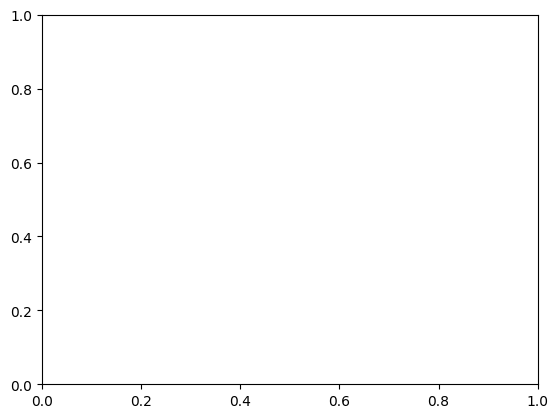

In [34]:
fig, ax = plt.subplots()

As you see above this produces a blank figure that we need to fill. As all the variables that we have seen until now (Numpy arrays, Pandas dataframe) the ```fig``` and ```ax``` objects have specific functions attached to them. ```ax``` in particular has all the plotting functions attached to it. In particular the simple ```plot()``` function, which takes two arguments: x values and y values:

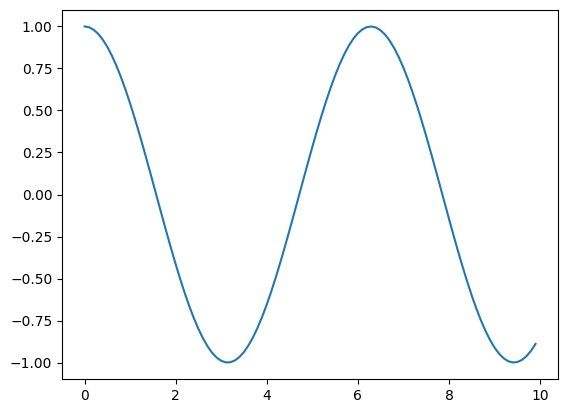

In [35]:
fig, ax = plt.subplots()
ax.plot(x_val, y_val);

That's it, we have our plot! We can easily add more data to it by just calling more times the ```ax.plot``` function. For example we can generate a new y signal for the sine:

In [36]:
y_val2 = np.sin(x_val)

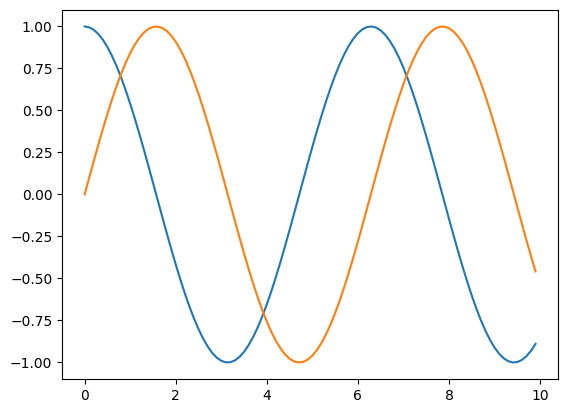

In [37]:
fig, ax = plt.subplots()
ax.plot(x_val, y_val);
ax.plot(x_val, y_val2);

We will see later how to adjust everything on this plot from colors to labels etc. The only additional point we show here is how to show every datapoint with a marker such as a circle using an additional parameter representing the line/marker type:

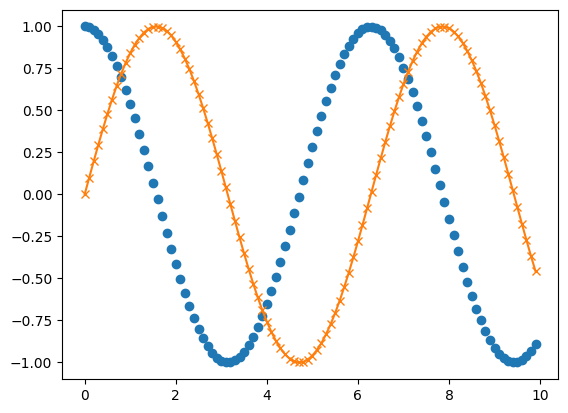

In [38]:
fig, ax = plt.subplots()
ax.plot(x_val, y_val,'o');
ax.plot(x_val, y_val2,'-x');

## Histogram

The other type of plot that is very useful, in particular when dealing with statistics, is the histogram. The principle of figure creation is the same. Except that now we use the ```ax.hist()``` commmand which takes only one argument, the values that we want to turn into a histogram:

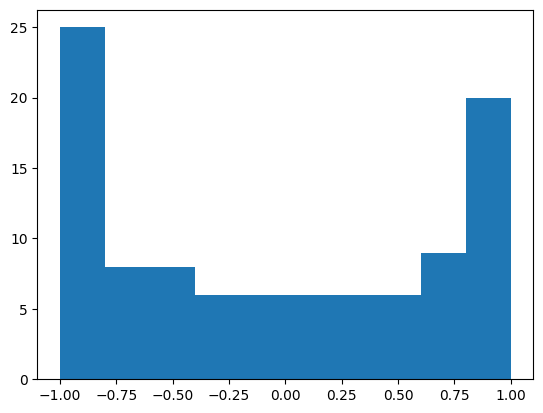

In [39]:
fig, ax = plt.subplots()
ax.hist(y_val);

Again, we will see how to specify more options for this plot. At the moment we only show that we can specify the position of the bins that we want to use for binning. This can be useful if the default bin size is not satisfactory. We can simply use the ```bins``` arguments and pass an array of positions:

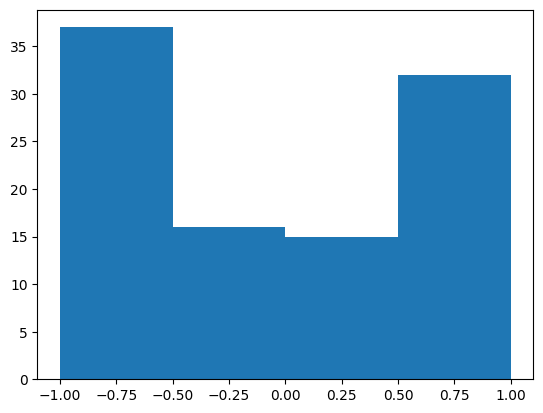

In [40]:
fig, ax = plt.subplots()
ax.hist(y_val, bins=np.arange(-1,1.5,0.5));

## Exercise 4,1

1. Using Pandas, import the CSV file located at https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv
2. Display the first 3 lines using the ```head()``` function.
3. Rembering that you can extract a given column from the table using ```my_dataframe['column_name']```, try to plot the ```bill_depth_mm```as as function of ```bill_length_mm``` using the ```plot``` function. Does it work ? Did you pass a Numpy array to the plotting function ?
4. Change the line/marker type so that you obtain a scatter plot, i.e. only single dots without a line

# Plotting on Dataframes

Humans are very bad at reading large datasets, i.e. tables. Therefore, we have algorithms creating descriptive statistics for us. These are either summary numbers or plots, i.e. vizualisations.

Pandas Dataframes have many [plotting](https://pandas.pydata.org/docs/reference/frame.html#plotting) methods. We practise some very useful ones here. The rest you can look up via the link.

In [53]:
import os
import pandas as pd

path = "train_ffv_feat.csv"
df = pd.read_csv(path)

df.head()

'''
try:
    from google.colab import drive
    drive.mount('/content/drive')

    path = "/content/drive/MyDrive/DSF-DCBP/data/train.csv"  # adjust based on your file location in Google Drive
    df = pd.read_csv(path)
    df.head()
except ImportError:
    print("Not running on Colab, load from local file system.")
    df = pd.read_csv('../data/train.csv') # adjust based on the path on your local machine
'''

'\ntry:\n    from google.colab import drive\n    drive.mount(\'/content/drive\')\n\n    path = "/content/drive/MyDrive/DSF-DCBP/data/train.csv"  # adjust based on your file location in Google Drive\n    df = pd.read_csv(path)\n    df.head()\nexcept ImportError:\n    print("Not running on Colab, load from local file system.")\n    df = pd.read_csv(\'../data/train.csv\') # adjust based on the path on your local machine\n'

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7973 entries, 0 to 7972
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       7973 non-null   int64  
 1   SMILES   7973 non-null   object 
 2   Tg       511 non-null    float64
 3   FFV      7030 non-null   float64
 4   Tc       737 non-null    float64
 5   Density  613 non-null    float64
 6   Rg       614 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 436.2+ KB


In [43]:
df.head()

,id,SMILES,Tg,FFV,Tc,Density,Rg
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,NaN,0.374645,0.205667,NaN,NaN
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,NaN,0.370410,NaN,NaN,NaN
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,NaN,0.378860,NaN,NaN,NaN
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,NaN,0.387324,NaN,NaN,NaN
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,NaN,0.355470,NaN,NaN,NaN


Histograms, or frequency plots, are much used as they show the probability density function pdf (continous data) of the data sample in a column. When dat a is discrete, it is called the probability mass function pmf. The pdf is the model of the data and the basis of all statistics.

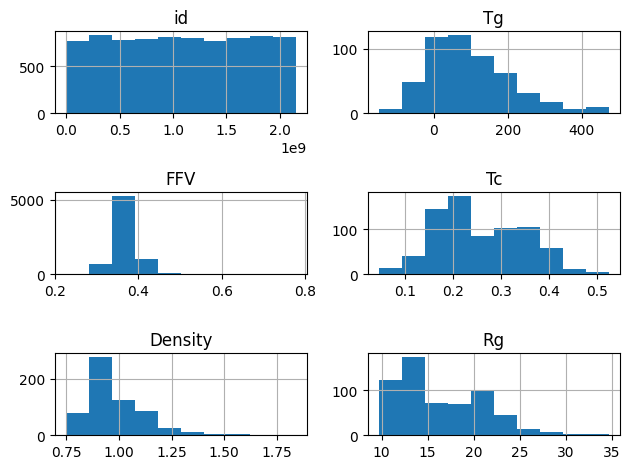

In [44]:
# Histograms of all the columns
df.hist()
plt.tight_layout()  # Adjust layout to prevent overlap

Let's take for example the lenght of SMILE values:

```python
df['smile_lenght'] = df['SMILES'].str.len()

plt.figure()
df["smiles_len"].hist(bins=50)
plt.xlabel("SMILES length")
plt.ylabel("Count")
plt.title("Distribution of SMILES length")
plt.show()
```

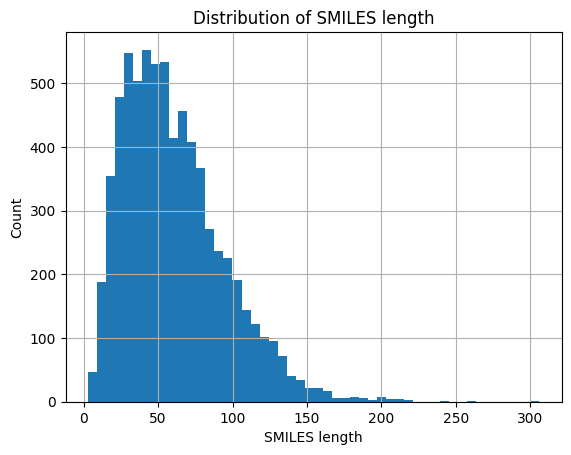

In [55]:
df['SMILES Length'] = df['SMILES'].str.len()

plt.figure()
df["SMILES Length"].hist(bins=50)
plt.xlabel("SMILES length")
plt.ylabel("Count")
plt.title("Distribution of SMILES length")
plt.show()

Box plots are useful for showing differences between groups of data. For example, we may be interested in the difference in the distributions between features.

<Axes: >

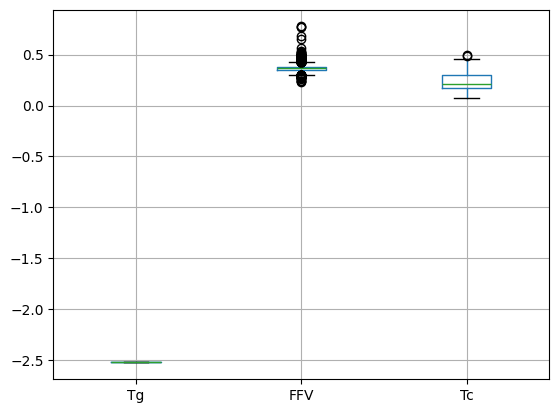

In [56]:
df.boxplot([df.columns[2], df.columns[3], df.columns[4]])

Here for example we see that Tg has a much broader distribution than the other two. So let's inspect only FFV and Tc:

<Axes: >

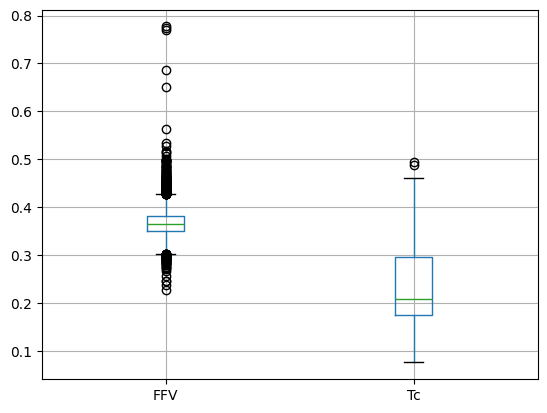

In [58]:
df.boxplot([df.columns[3], df.columns[4]])

Another useful plot is the one showing the number of missing values per column. We can use a barplot for it:

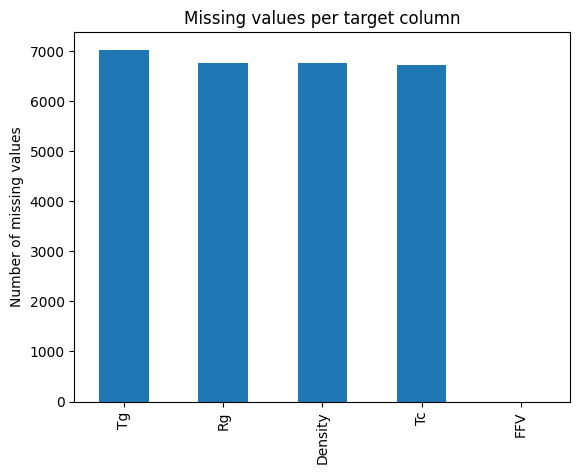

In [59]:
target_cols = ["Tg", "FFV", "Tc", "Density", "Rg"]
missing = df[target_cols].isna().sum().sort_values(ascending=False)

plt.figure()
missing.plot(kind="bar")
plt.ylabel("Number of missing values")
plt.title("Missing values per target column")
plt.show()

Very often one is also interested in correlations between columns (features) of the data. The visualisation of correlations is done with scatter plots. Here is the simplest one.

<Axes: xlabel='FFV', ylabel='Tc'>

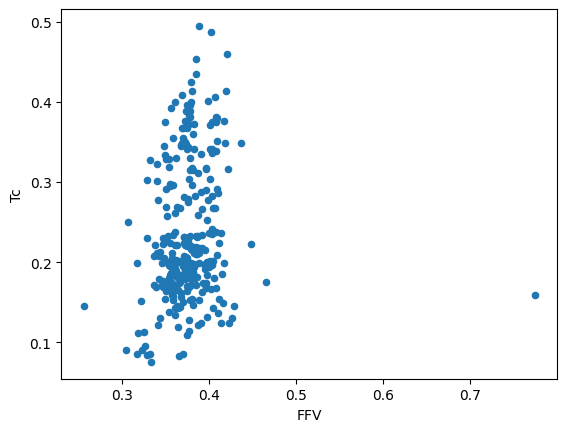

In [60]:
#df.plot.scatter(df[df.columns[3]],df[df.columns[4]])
df.plot.scatter(3,4)

You may take a short look at the other plotting methods on dataframes [here](https://pandas.pydata.org/docs/reference/frame.html#plotting).

# Descriptive Statistics on Dataframes

Pandas Dataframes have several
[descriptive statistics](https://pandas.pydata.org/docs/reference/frame.html#computations-descriptive-stats) methods. Most of them are calculations based on the so-called moments of the pdf (mean, variance, standard deviation, skew, kurtosis, minimum value, maximum value, quantiles, p-value ...)

We practise some very useful ones. The rest you can look up in the API documentation via the link.

In [61]:
round(df.describe(), 2) # why do we use the round method ?

,id,Tg,FFV,Tc,Density,Rg,SMILES Length,Stars,Carbons,Oxygens,Nitrogens,Equals
count,7.030000e+03,1.00,7030.00,300.00,270.00,270.00,7030.00,7030.00,7030.00,7030.00,7030.00,7030.00
mean,1.078609e+09,-2.53,0.37,0.23,1.01,15.76,60.89,2.00,26.98,3.63,1.72,2.26
std,6.207845e+08,NaN,0.03,0.09,0.16,4.58,33.64,0.08,15.28,2.97,1.68,2.07
min,8.781700e+04,-2.53,0.23,0.08,0.75,9.77,3.00,1.00,0.00,0.00,0.00,0.00
25%,5.436875e+08,-2.53,0.35,0.17,0.90,12.20,35.00,2.00,15.00,1.00,0.00,0.00
50%,1.076305e+09,-2.53,0.36,0.21,0.98,13.90,55.00,2.00,25.00,4.00,2.00,2.00
75%,1.621402e+09,-2.53,0.38,0.30,1.09,19.40,79.00,2.00,36.00,6.00,2.00,4.00
max,2.147438e+09,-2.53,0.78,0.49,1.84,29.40,306.00,4.00,133.00,38.00,14.00,16.00


In [62]:
# Try some other descriptive methods here.


# Exercise 4.2

* Plot the histogram of the FFV feature

* Plot the Relationship between Density and FFV as a scatter plot

* Plot a Correlation heatmap among numeric columns

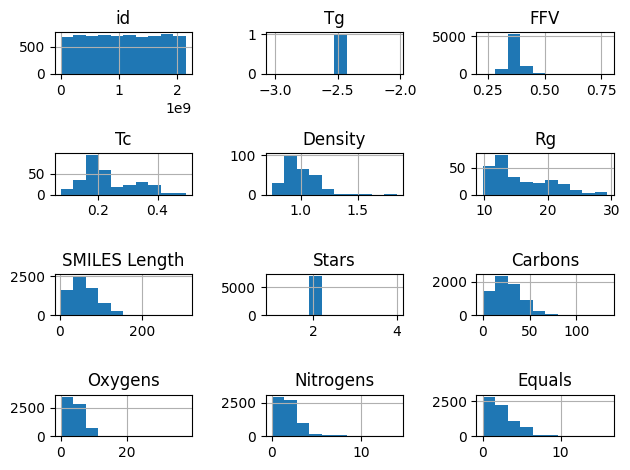

In [86]:
import os
import pandas as pd

path = "train_ffv_feat.csv"
df = pd.read_csv(path)

df.hist()
plt.tight_layout()  # Adjust layout to prevent overlap

<Axes: xlabel='FFV', ylabel='Density'>

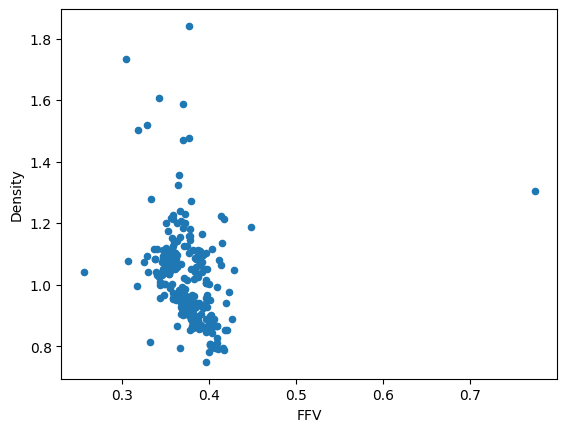

In [70]:
df.plot.scatter(3,5)

<Axes: >

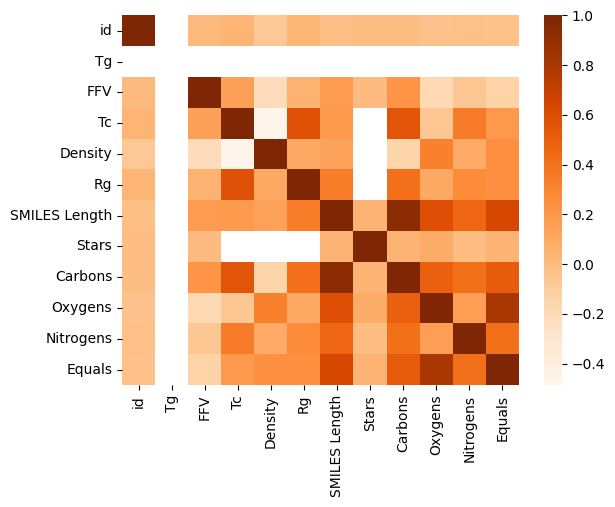

In [84]:
import seaborn as sns

# calculate the correlation matrix on the numeric columns
corr = df.select_dtypes('number').corr()

# plot the heatmap
sns.heatmap(corr, cmap="Oranges", annot=False)

Now fill this [form](https://docs.google.com/forms/d/e/1FAIpQLSd5QH237yJ2PizRG1Of8mV9zDzcJLH6nmEI2KqVX1cWINi9Fg/viewform?usp=sf_link), needed for getting participation assignment points